# TF-IDF

### TF-IDF + Engineered Features (Logistic Regression): Binary and Ordinal Benchmarks

This chunk builds a strong **linear baseline** by combining **TF-IDF vectors** with **engineered features** (VADER scores and stylometric indicators such as length, capitalization, and punctuation) into a single hybrid input matrix.

Two tasks are evaluated:

- **Task A — Binary polarity classification (1–2 vs 4–5, excluding 3-star reviews):**  
  A **10-fold stratified cross-validation** procedure is used to tune the decision threshold by maximizing **Macro-F1**, while also applying **class-weight balancing** to mitigate class imbalance. The final model is then trained on the full training set and evaluated on the test set.

- **Task B — Ordinal 1–5 rating prediction (cumulative link approach):**  
  The 5-class problem is modeled as **four cumulative binary classifiers** estimating \(P(y>k)\) for \(k \in \{1,2,3,4\}\). **Out-of-fold (OOF) probabilities** are computed via 10-fold CV to avoid leakage during threshold selection. A grid search is then performed to select the four thresholds that minimize **MAE**. Finally, the four classifiers are retrained on the full training set and evaluated on the test set, reporting both **MAE** and the **confusion matrix**.


Mounted at /content/drive
1) Loading Dataset (CSV)...
2) Loading TF-IDF Vectors (PKL)...
   Train TF-IDF Shape: (958686, 5000)
   Test  TF-IDF Shape: (239672, 5000)

3) Preparing Extra Features (VADER + Structural)...
   Final Train Matrix: (958686, 5008)
   Final Test  Matrix: (239672, 5008)

TASK A: BINARY CLASSIFICATION (TF-IDF + EXTRA) + 10-fold threshold tuning
Logic: remove 3-star reviews. (1,2)->0, (4,5)->1
Class weights (binary): {np.int64(0): np.float64(3.175144219273075), np.int64(1): np.float64(0.5934529055289338)}

--- Fold 1/10 (Binary) ---

--- Fold 2/10 (Binary) ---

--- Fold 3/10 (Binary) ---

--- Fold 4/10 (Binary) ---

--- Fold 5/10 (Binary) ---

--- Fold 6/10 (Binary) ---

--- Fold 7/10 (Binary) ---

--- Fold 8/10 (Binary) ---

--- Fold 9/10 (Binary) ---

--- Fold 10/10 (Binary) ---

=== Binary Threshold CV Results (Macro-F1) ===
Threshold 0.10 → Mean Macro-F1: 0.9329
Threshold 0.20 → Mean Macro-F1: 0.9413
Threshold 0.30 → Mean Macro-F1: 0.9400
Threshold 0.40 → Mean 

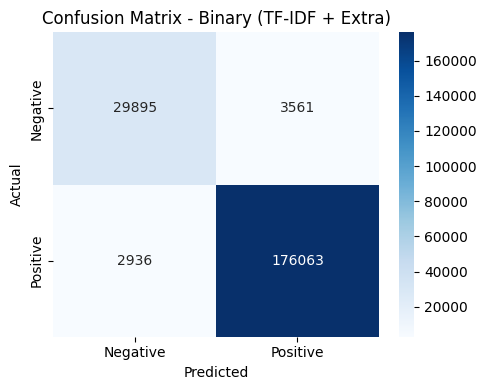


TASK B: ORDINAL MULTICLASS (TF-IDF + EXTRA) - 4 cumulative binaries + OOF probs
Models: P(y>1), P(y>2), P(y>3), P(y>4). Prediction: 1 + (#thresholds exceeded)

[OOF] Building OOF probabilities with 10-fold CV...

--- Fold 1/10 (Ordinal) ---

--- Fold 2/10 (Ordinal) ---

--- Fold 3/10 (Ordinal) ---

--- Fold 4/10 (Ordinal) ---

--- Fold 5/10 (Ordinal) ---

--- Fold 6/10 (Ordinal) ---

--- Fold 7/10 (Ordinal) ---

--- Fold 8/10 (Ordinal) ---

--- Fold 9/10 (Ordinal) ---

--- Fold 10/10 (Ordinal) ---

[OOF] Grid search thresholds (MAE) on OOF probabilities...

BEST THRESHOLDS (OOF-CV): (0.3, 0.3, 0.3, 0.5)
BEST OOF-CV MAE: 0.38708398787507065

[FINAL] Training 4 ordinal models on the full TRAIN set...

[FINAL] Predicting probabilities on TEST for the 4 thresholds...

--- TEST RESULTS (Ordinal) ---
              precision    recall  f1-score   support

           1       0.55      0.86      0.67     16768
           2       0.39      0.31      0.35     16688
           3       0.51      0

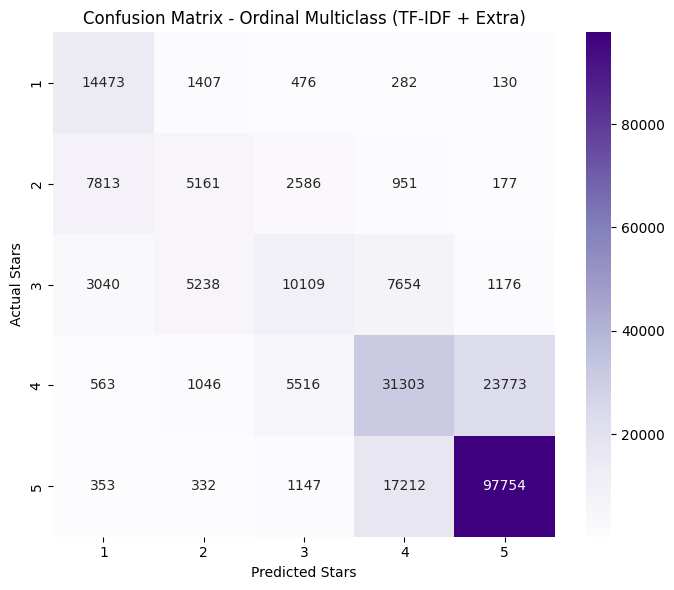

In [ ]:
# ============================================================
# TF-IDF + EXTRA FEATURES  |  BINARY + ORDINAL (OOF PROBS)
# - Task A: Binary (1,2)->0 ; (4,5)->1 ; 3 excluded
#   -> 10-fold Stratified CV for threshold tuning (Macro-F1) + class_weight
# - Task B: Ordinal Multiclass (1..5) as 4 cumulative binary classifiers P(y>k)
#   -> OOF probabilities (10-fold) + grid search thresholds to minimize MAE
#   -> Final training on full train set + test report + MAE + confusion matrix
# ============================================================

import pandas as pd
import numpy as np
import os
import joblib
from itertools import product

from scipy.sparse import hstack
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, accuracy_score, confusion_matrix,
    f1_score, mean_absolute_error
)

import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# ----------------------------------------------------
# 0. CONFIG
# ----------------------------------------------------
RANDOM_STATE = 42
N_SPLITS = 10

# Binary threshold tuning
THRESHOLD_GRID_BIN = [0.1, 0.2, 0.3, 0.4, 0.5]

# Ordinal threshold tuning (4 thresholds)
THRESHOLD_GRID_ORD = [0.3, 0.4, 0.5, 0.6]

# Logistic Regression params
LR_KWARGS = dict(
    max_iter=1000,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

# ----------------------------------------------------
# 1. SETUP AND LOADING
# ----------------------------------------------------
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/MAGISTRALE/Text_Mining/Datasets'
VECTORS_PATH = os.path.join(DRIVE_PATH, 'vectors')

print("1) Loading Dataset (CSV)...")
df_train = pd.read_csv(os.path.join(DRIVE_PATH, 'train_dataset.csv'))
df_test  = pd.read_csv(os.path.join(DRIVE_PATH, 'test_dataset.csv'))

print("2) Loading TF-IDF Vectors (PKL)...")
tfidf_train = joblib.load(os.path.join(VECTORS_PATH, 'tfidf_train.pkl'))
tfidf_test  = joblib.load(os.path.join(VECTORS_PATH, 'tfidf_test.pkl'))

print(f"   Train TF-IDF Shape: {tfidf_train.shape}")
print(f"   Test  TF-IDF Shape: {tfidf_test.shape}")

# ----------------------------------------------------
# 2. EXTRA FEATURE PREPARATION
# ----------------------------------------------------
print("\n3) Preparing Extra Features (VADER + Structural)...")
feature_cols = [
    'vader_pos', 'vader_neg', 'vader_neu',
    'num_exclamations', 'caps_ratio',
    'review_len_words', 'review_len_chars', 'num_questions'
]

X_train_feats = df_train[feature_cols].values
X_test_feats  = df_test[feature_cols].values

scaler = MinMaxScaler()
X_train_feats_scaled = scaler.fit_transform(np.nan_to_num(X_train_feats))
X_test_feats_scaled  = scaler.transform(np.nan_to_num(X_test_feats))

# Final matrix: [TF-IDF | Extra Features]
X_train_full = hstack([tfidf_train, X_train_feats_scaled]).tocsr()
X_test_full  = hstack([tfidf_test,  X_test_feats_scaled]).tocsr()

print(f"   Final Train Matrix: {X_train_full.shape}")
print(f"   Final Test  Matrix: {X_test_full.shape}")

y_train_original = df_train['stars_review']
y_test_original  = df_test['stars_review']

# ============================================================
# A) BINARY CLASSIFICATION (OOF threshold tuning)
# ============================================================
print("\n" + "="*60)
print("TASK A: BINARY CLASSIFICATION (TF-IDF + EXTRA) + 10-fold threshold tuning")
print("="*60)
print("Logic: remove 3-star reviews. (1,2)->0, (4,5)->1")

mask_train = (y_train_original != 3)
mask_test  = (y_test_original  != 3)

X_train_bin = X_train_full[mask_train.values, :]
X_test_bin  = X_test_full[mask_test.values, :]

y_train_bin = y_train_original[mask_train].apply(lambda x: 0 if x <= 2 else 1).astype(int)
y_test_bin  = y_test_original[mask_test].apply(lambda x: 0 if x <= 2 else 1).astype(int)

# class_weight "balanced" computed on binary train set
classes_bin = np.array([0, 1])
weights_bin = compute_class_weight(
    class_weight='balanced',
    classes=classes_bin,
    y=y_train_bin.values
)
class_weight_bin = dict(zip(classes_bin, weights_bin))
print("Class weights (binary):", class_weight_bin)

# 10-fold Stratified CV: train on fold-train, predict probs on fold-val (OOF per fold)
skf_bin = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
threshold_scores_bin = {t: [] for t in THRESHOLD_GRID_BIN}

for fold, (tr_idx, val_idx) in enumerate(skf_bin.split(X_train_bin, y_train_bin), 1):
    print(f"\n--- Fold {fold}/{N_SPLITS} (Binary) ---")

    X_tr, X_val = X_train_bin[tr_idx], X_train_bin[val_idx]
    y_tr, y_val = y_train_bin.iloc[tr_idx], y_train_bin.iloc[val_idx]

    model = LogisticRegression(class_weight=class_weight_bin, **LR_KWARGS)
    model.fit(X_tr, y_tr)

    y_val_proba = model.predict_proba(X_val)[:, 1]

    for t in THRESHOLD_GRID_BIN:
        y_val_pred = (y_val_proba > t).astype(int)
        f1 = f1_score(y_val, y_val_pred, average='macro')
        threshold_scores_bin[t].append(f1)

avg_scores_bin = {t: float(np.mean(v)) for t, v in threshold_scores_bin.items()}
best_threshold_bin = max(avg_scores_bin, key=avg_scores_bin.get)

print("\n=== Binary Threshold CV Results (Macro-F1) ===")
for t, score in avg_scores_bin.items():
    print(f"Threshold {t:.2f} → Mean Macro-F1: {score:.4f}")
print(f"\n✅ Best threshold selected (binary): {best_threshold_bin:.2f}")

# Final binary training on full train set
final_model_bin = LogisticRegression(class_weight=class_weight_bin, **LR_KWARGS)
final_model_bin.fit(X_train_bin, y_train_bin)

# Final binary test
y_test_proba_bin = final_model_bin.predict_proba(X_test_bin)[:, 1]
y_test_pred_bin  = (y_test_proba_bin > best_threshold_bin).astype(int)

print("\n=== FINAL TEST RESULTS (Binary) ===")
print(f"Threshold used: {best_threshold_bin:.2f}")
print(classification_report(y_test_bin, y_test_pred_bin, target_names=["Negative", "Positive"]))

cm_bin = confusion_matrix(y_test_bin, y_test_pred_bin, labels=[0, 1])
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_bin, annot=True, fmt='d', cmap='Blues',
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.title("Confusion Matrix - Binary (TF-IDF + Extra)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ============================================================
# B) ORDINAL MULTICLASS (OOF probabilities + MAE threshold tuning)
# ============================================================
print("\n" + "="*60)
print("TASK B: ORDINAL MULTICLASS (TF-IDF + EXTRA) - 4 cumulative binaries + OOF probs")
print("="*60)
print("Models: P(y>1), P(y>2), P(y>3), P(y>4). Prediction: 1 + (#thresholds exceeded)")

def make_ordinal_target(y, k):
    # returns 1 if y>k, otherwise 0
    return (y > k).astype(int)

def predict_with_thresholds(probs_4, thresholds_4):
    # probs_4: (n,4), thresholds_4: (4,)
    y_pred = 1 + (probs_4 > thresholds_4).sum(axis=1)
    return np.clip(y_pred, 1, 5)

# OOF probs: for each train sample, probability estimated by a model that did NOT see it
oof_probs = np.zeros((X_train_full.shape[0], 4), dtype=np.float32)

# StratifiedKFold on original 1..5 labels (preserve star distribution)
skf_ord = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

print(f"\n[OOF] Building OOF probabilities with {N_SPLITS}-fold CV...")
for fold, (tr_idx, val_idx) in enumerate(skf_ord.split(X_train_full, y_train_original), 1):
    print(f"\n--- Fold {fold}/{N_SPLITS} (Ordinal) ---")

    X_tr, X_val = X_train_full[tr_idx], X_train_full[val_idx]
    y_tr_full = y_train_original.iloc[tr_idx]
    y_val_full = y_train_original.iloc[val_idx]

    # for each k train a binary model on fold-train and predict probs on fold-val
    for j, k in enumerate([1, 2, 3, 4]):
        y_tr_bin_k = make_ordinal_target(y_tr_full, k)
        y_val_bin_k = make_ordinal_target(y_val_full, k)

        # balanced class_weight for the fold-specific binary task
        classes_k = np.array([0, 1])
        weights_k = compute_class_weight(
            class_weight='balanced',
            classes=classes_k,
            y=y_tr_bin_k.values
        )
        class_weight_k = dict(zip(classes_k, weights_k))

        model_k = LogisticRegression(class_weight=class_weight_k, **LR_KWARGS)
        model_k.fit(X_tr, y_tr_bin_k)

        oof_probs[val_idx, j] = model_k.predict_proba(X_val)[:, 1].astype(np.float32)

# Grid search thresholds on OOF probs to minimize MAE
print("\n[OOF] Grid search thresholds (MAE) on OOF probabilities...")
best_mae = np.inf
best_thresholds_ord = None

y_true_train_ord = y_train_original.values

for thresholds in product(THRESHOLD_GRID_ORD, repeat=4):
    thr = np.array(thresholds, dtype=np.float32)
    y_pred_cv = predict_with_thresholds(oof_probs, thr)
    mae = mean_absolute_error(y_true_train_ord, y_pred_cv)

    if mae < best_mae:
        best_mae = mae
        best_thresholds_ord = thresholds

print("\n==============================")
print("BEST THRESHOLDS (OOF-CV):", best_thresholds_ord)
print("BEST OOF-CV MAE:", float(best_mae))
print("==============================")

best_thr_ord = np.array(best_thresholds_ord, dtype=np.float32)

# Final training: 4 ordinal models on the FULL training set
print("\n[FINAL] Training 4 ordinal models on the full TRAIN set...")
final_models_ord = {}
for k in [1, 2, 3, 4]:
    y_train_bin_k = make_ordinal_target(y_train_original, k)

    classes_k = np.array([0, 1])
    weights_k = compute_class_weight(
        class_weight='balanced',
        classes=classes_k,
        y=y_train_bin_k.values
    )
    class_weight_k = dict(zip(classes_k, weights_k))

    model_k = LogisticRegression(class_weight=class_weight_k, **LR_KWARGS)
    model_k.fit(X_train_full, y_train_bin_k)
    final_models_ord[k] = model_k

# Probabilities on TEST set
print("\n[FINAL] Predicting probabilities on TEST for the 4 thresholds...")
probs_test_ord = np.zeros((X_test_full.shape[0], 4), dtype=np.float32)
for j, k in enumerate([1, 2, 3, 4]):
    probs_test_ord[:, j] = final_models_ord[k].predict_proba(X_test_full)[:, 1].astype(np.float32)

# Final ordinal prediction + evaluation
y_test_pred_ord = predict_with_thresholds(probs_test_ord, best_thr_ord)
y_test_true_ord = y_test_original.values

print("\n--- TEST RESULTS (Ordinal) ---")
print(classification_report(y_test_true_ord, y_test_pred_ord))
print("Final MAE (Test):", float(mean_absolute_error(y_test_true_ord, y_test_pred_ord)))

cm_ord = confusion_matrix(y_test_true_ord, y_test_pred_ord, labels=[1, 2, 3, 4, 5])
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_ord, annot=True, fmt='d', cmap='Purples',
    xticklabels=[1,2,3,4,5],
    yticklabels=[1,2,3,4,5]
)
plt.title("Confusion Matrix - Ordinal Multiclass (TF-IDF + Extra)")
plt.xlabel("Predicted Stars")
plt.ylabel("Actual Stars")
plt.tight_layout()
plt.show()


# BERT

### BERT Embeddings + Engineered Features (MLP): Binary and Ordinal Deep Learning Baselines

This chunk replaces sparse TF-IDF features with **pre-computed BERT embeddings** to capture deeper semantic context, and trains a **Multi-Layer Perceptron (MLP)** classifier. The input to the network is a **hybrid vector** obtained by concatenating **BERT embeddings** with **engineered features** (VADER sentiment scores and structural cues such as length, punctuation, and capitalization). Training is performed in **mini-batches** using `partial_fit` for scalability.

Two tasks are implemented:

- **Task A — Binary polarity classification (1–2 vs 4–5, excluding 3-star reviews):**  
  A train/validation split is created from the filtered training set, and the MLP is trained for multiple epochs. Validation accuracy is monitored each epoch, and the final model is evaluated on the filtered test set with a classification report and confusion matrix.

- **Task B — Ordinal 1–5 rating prediction (cumulative link approach):**  
  The 5-class problem is modeled as **four cumulative binary classifiers** estimating \(P(y>k)\) for \(k \in \{1,2,3,4\}\). To avoid biased threshold selection, **out-of-fold (OOF) probabilities** are computed using **10-fold stratified CV**, and a grid search is performed to select the four decision thresholds that minimize **MAE**. Finally, the four models are retrained on the full training set and evaluated on the test set, reporting **MAE** and the confusion matrix.


1) Loading Dataset (CSV)...
2) Loading BERT Embeddings (NPY, mmap_mode='r')...
   Train BERT Shape: (958686, 384)
   Test  BERT Shape: (239672, 384)
3) Preparing Extra Features (VADER + Structural)...

TASK A) BINARY (BERT) - (1,2)->0 | (4,5)->1 | 3 excluded
Class distribution TRAIN (binary):
stars_review
1.0    0.842527
0.0    0.157473
Name: proportion, dtype: float64

Starting BINARY training for 5 epochs...

--- EPOCH 1/5 ---


Training Batch (Binary):   0%|          | 0/764838 [00:00<?, ?it/s]

Validating (Binary):   0%|          | 0/84983 [00:00<?, ?it/s]

   >> Validation Accuracy: 0.9560

--- EPOCH 2/5 ---


Training Batch (Binary):   0%|          | 0/764838 [00:00<?, ?it/s]

...

Training Batch (Binary):   0%|          | 0/764838 [00:00<?, ?it/s]

Validating (Binary):   0%|          | 0/84983 [00:00<?, ?it/s]

   >> Validation Accuracy: 0.9593

--- FINAL TEST (Binary) ---


Predict Test (Binary):   0%|          | 0/212455 [00:00<?, ?it/s]

              precision    recall  f1-score   support

    Negative       0.89      0.85      0.87     33456
    Positive       0.97      0.98      0.98    178999

    accuracy                           0.96    212455
   macro avg       0.93      0.91      0.92    212455
weighted avg       0.96      0.96      0.96    212455



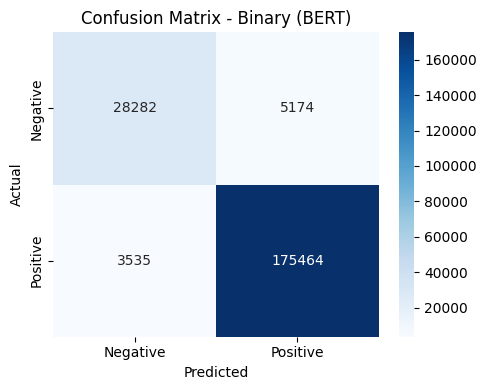


TASK B) ORDINAL MULTICLASS (BERT) = 4 cumulative binaries + threshold tuning (MAE)
Models: P(y>1), P(y>2), P(y>3), P(y>4).  Pred: 1 + (#thresholds exceeded).

[CV] Building OOF probabilities with 10-fold (EPOCHS_CV=1)...

--- Fold 1/10 | Train=862817 Val=95869 ---


Training Fold1 P(y>1) ep1:   0%|          | 0/862817 [00:00<?, ?it/s]

Predict Fold1 VAL proba P(y>1):   0%|          | 0/95869 [00:00<?, ?it/s]

Training Fold1 P(y>2) ep1:   0%|          | 0/862817 [00:00<?, ?it/s]

Predict Fold1 VAL proba P(y>2):   0%|          | 0/95869 [00:00<?, ?it/s]

...

Predict TEST proba P(y>1):   0%|          | 0/239672 [00:00<?, ?it/s]

Predict TEST proba P(y>2):   0%|          | 0/239672 [00:00<?, ?it/s]

Predict TEST proba P(y>3):   0%|          | 0/239672 [00:00<?, ?it/s]

Predict TEST proba P(y>4):   0%|          | 0/239672 [00:00<?, ?it/s]


--- TEST RESULTS (Ordinal) ---
              precision    recall  f1-score   support

           1       0.71      0.64      0.67     16768
           2       0.43      0.37      0.39     16688
           3       0.45      0.42      0.43     27217
           4       0.49      0.45      0.47     62201
           5       0.76      0.84      0.80    116798

    accuracy                           0.64    239672
   macro avg       0.57      0.54      0.55    239672
weighted avg       0.63      0.64      0.63    239672

Final MAE (Test): 0.4106028238592743


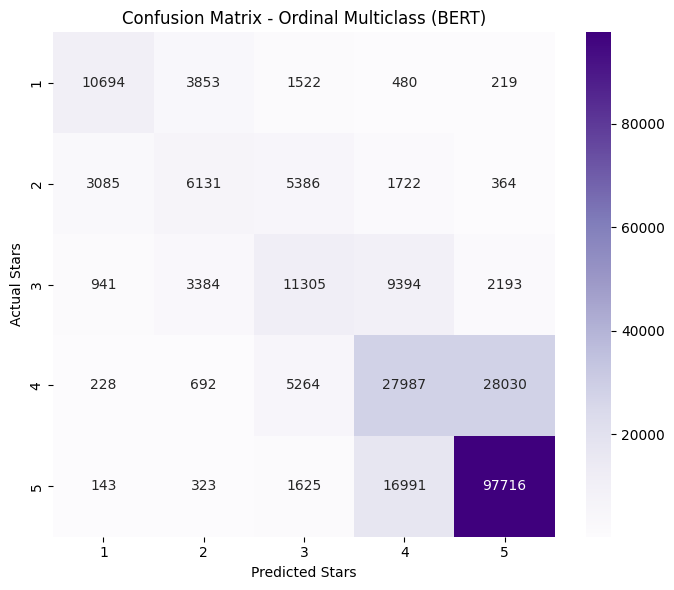

5995

In [ ]:
import pandas as pd
import numpy as np
import os
import gc
from itertools import product

from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, accuracy_score, confusion_matrix, mean_absolute_error
)
from sklearn.model_selection import train_test_split, StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from google.colab import drive

# ==============================================================================
# 0) CONFIG
# ==============================================================================
RANDOM_STATE = 42
BATCH_SIZE = 50000

# TASK A (Binary)
EPOCHS_BIN = 5

# TASK B (Ordinal: 4 cumulative binaries)
N_SPLITS = 10
EPOCHS_ORD_CV = 1        # OOF CV: low because it is costly (10-fold * 4 models)
EPOCHS_ORD_FINAL = 5     # Final training on the full train set
THRESHOLD_GRID = [0.3, 0.4, 0.5, 0.6]  # grid for each of the 4 thresholds

# ==============================================================================
# 1) SETUP + LOAD
# ==============================================================================
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/MAGISTRALE/Text_Mining/Datasets'
VECTORS_PATH = os.path.join(DRIVE_PATH, 'vectors')

print("1) Loading Dataset (CSV)...")
df_train = pd.read_csv(os.path.join(DRIVE_PATH, 'train_dataset.csv'))
df_test  = pd.read_csv(os.path.join(DRIVE_PATH, 'test_dataset.csv'))

print("2) Loading BERT Embeddings (NPY, mmap_mode='r')...")
bert_train = np.load(os.path.join(VECTORS_PATH, 'bert_train.npy'), mmap_mode='r')
bert_test  = np.load(os.path.join(VECTORS_PATH, 'bert_test.npy'),  mmap_mode='r')
print(f"   Train BERT Shape: {bert_train.shape}")
print(f"   Test  BERT Shape: {bert_test.shape}")

print("3) Preparing Extra Features (VADER + Structural)...")
feature_cols = [
    'vader_pos', 'vader_neg', 'vader_neu',
    'num_exclamations', 'caps_ratio', 'review_len_words',
    'review_len_chars', 'num_questions'
]

X_train_feats = df_train[feature_cols].values
X_test_feats  = df_test[feature_cols].values

scaler = MinMaxScaler()
X_train_feats_scaled = scaler.fit_transform(np.nan_to_num(X_train_feats))
X_test_feats_scaled  = scaler.transform(np.nan_to_num(X_test_feats))

y_train_original = df_train['stars_review']
y_test_original  = df_test['stars_review']

# Safety: assume RangeIndex 0..n-1; if not, realign
df_train = df_train.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)
y_train_original = y_train_original.reset_index(drop=True)
y_test_original  = y_test_original.reset_index(drop=True)

# ==============================================================================
# 2) UTILS: batch train / predict / predict_proba
# ==============================================================================
def train_epoch(model, indices, X_bert, X_feats, y_full, batch_size=BATCH_SIZE, classes=None, desc="Training"):
    indices = np.array(indices, dtype=int)
    np.random.shuffle(indices)

    with tqdm(total=len(indices), desc=desc) as pbar:
        for start in range(0, len(indices), batch_size):
            end = min(start + batch_size, len(indices))
            batch_idx = indices[start:end]

            X_batch = np.hstack((X_bert[batch_idx], X_feats[batch_idx]))
            # y_full is a Series aligned on RangeIndex => .iloc is ok with batch_idx
            y_batch = y_full.iloc[batch_idx].values

            model.partial_fit(X_batch, y_batch, classes=classes)

            del X_batch
            pbar.update(len(batch_idx))
    return model

def predict_full(model, indices, X_bert, X_feats, batch_size=BATCH_SIZE, desc="Predict"):
    indices = np.array(indices, dtype=int)
    preds = []

    with tqdm(total=len(indices), desc=desc) as pbar:
        for start in range(0, len(indices), batch_size):
            end = min(start + batch_size, len(indices))
            idx = indices[start:end]

            X_batch = np.hstack((X_bert[idx], X_feats[idx]))
            preds.extend(model.predict(X_batch))
            del X_batch
            pbar.update(len(idx))

    return np.array(preds)

def predict_proba_pos_full(model, indices, X_bert, X_feats, batch_size=BATCH_SIZE, desc="Predict proba(pos)"):
    indices = np.array(indices, dtype=int)
    probs = []

    with tqdm(total=len(indices), desc=desc) as pbar:
        for start in range(0, len(indices), batch_size):
            end = min(start + batch_size, len(indices))
            idx = indices[start:end]

            X_batch = np.hstack((X_bert[idx], X_feats[idx]))
            probs.extend(model.predict_proba(X_batch)[:, 1])
            del X_batch
            pbar.update(len(idx))

    return np.array(probs)

# ==============================================================================
# 3) TASK A: BINARY (as in the "second code": standard predict(), no threshold tuning)
# ==============================================================================
print("\n" + "="*70)
print("TASK A) BINARY (BERT) - (1,2)->0 | (4,5)->1 | 3 excluded")
print("="*70)

train_idx_bin_all = np.where((y_train_original != 3).values)[0]
test_idx_bin      = np.where((y_test_original  != 3).values)[0]

# (1,2)->0, (4,5)->1 (3-star reviews are excluded via indices)
y_train_bin = y_train_original.apply(lambda x: 0 if x <= 2 else (1 if x >= 4 else np.nan))
y_test_bin  = y_test_original.apply(lambda x: 0 if x <= 2 else (1 if x >= 4 else np.nan))

train_idx_A, val_idx_A = train_test_split(
    train_idx_bin_all,
    test_size=0.10,
    random_state=RANDOM_STATE,
    stratify=y_train_bin.iloc[train_idx_bin_all]
)

print("Class distribution TRAIN (binary):")
print(y_train_bin.iloc[train_idx_bin_all].value_counts(normalize=True))

model_bin = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128),
    activation='relu',
    solver='adam',
    random_state=RANDOM_STATE,
    max_iter=1,
    warm_start=True,
    alpha=0.0001
)

print(f"\nStarting BINARY training for {EPOCHS_BIN} epochs...")
for epoch in range(EPOCHS_BIN):
    print(f"\n--- EPOCH {epoch+1}/{EPOCHS_BIN} ---")
    model_bin = train_epoch(
        model=model_bin,
        indices=train_idx_A,
        X_bert=bert_train,
        X_feats=X_train_feats_scaled,
        y_full=y_train_bin,
        classes=[0, 1],
        desc="Training Batch (Binary)"
    )

    y_val_pred = predict_full(
        model_bin, val_idx_A, bert_train, X_train_feats_scaled,
        desc="Validating (Binary)"
    )
    y_val_true = y_train_bin.iloc[val_idx_A].values
    val_acc = accuracy_score(y_val_true, y_val_pred)
    print(f"   >> Validation Accuracy: {val_acc:.4f}")

print("\n--- FINAL TEST (Binary) ---")
y_test_pred_bin = predict_full(
    model_bin, test_idx_bin, bert_test, X_test_feats_scaled,
    desc="Predict Test (Binary)"
)
y_test_true_bin = y_test_bin.iloc[test_idx_bin].values

print(classification_report(y_test_true_bin, y_test_pred_bin, target_names=["Negative", "Positive"]))

cm_bin = confusion_matrix(y_test_true_bin, y_test_pred_bin, labels=[0, 1])
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_bin, annot=True, fmt='d', cmap='Blues',
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.title("Confusion Matrix - Binary (BERT)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ==============================================================================
# 4) TASK B: ORDINAL MULTICLASS = 4 cumulative binaries + threshold tuning (MAE) via OOF 10-fold
# ==============================================================================
print("\n" + "="*70)
print("TASK B) ORDINAL MULTICLASS (BERT) = 4 cumulative binaries + threshold tuning (MAE)")
print("="*70)
print("Models: P(y>1), P(y>2), P(y>3), P(y>4).  Pred: 1 + (#thresholds exceeded).")

def make_ord_target(y, k):
    return (y > k).astype(int)

train_idx_ord = np.arange(len(df_train))
test_idx_ord  = np.arange(len(df_test))

# Ordinal targets for train (Series aligned)
y_train_ord = {k: make_ord_target(y_train_original, k) for k in [1, 2, 3, 4]}

# ------------------------------------------------------------------
# 4.1) OOF probabilities (10-fold) to avoid bias in threshold tuning
# ------------------------------------------------------------------
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
oof_probs = np.zeros((len(train_idx_ord), 4), dtype=np.float32)

print(f"\n[CV] Building OOF probabilities with {N_SPLITS}-fold (EPOCHS_CV={EPOCHS_ORD_CV})...")

for fold, (tr_pos, val_pos) in enumerate(skf.split(train_idx_ord, y_train_original.values), 1):
    tr_idx  = train_idx_ord[tr_pos]
    val_idx = train_idx_ord[val_pos]

    print(f"\n--- Fold {fold}/{N_SPLITS} | Train={len(tr_idx)} Val={len(val_idx)} ---")

    for j, k in enumerate([1, 2, 3, 4]):
        model_k = MLPClassifier(
            hidden_layer_sizes=(512, 256, 128),
            activation='relu',
            solver='adam',
            random_state=RANDOM_STATE,
            max_iter=1,
            warm_start=True,
            alpha=0.0001
        )

        for ep in range(EPOCHS_ORD_CV):
            model_k = train_epoch(
                model=model_k,
                indices=tr_idx,
                X_bert=bert_train,
                X_feats=X_train_feats_scaled,
                y_full=y_train_ord[k],
                classes=[0, 1],
                desc=f"Training Fold{fold} P(y>{k}) ep{ep+1}"
            )

        oof_probs[val_idx, j] = predict_proba_pos_full(
            model_k,
            indices=val_idx,
            X_bert=bert_train,
            X_feats=X_train_feats_scaled,
            desc=f"Predict Fold{fold} VAL proba P(y>{k})"
        ).astype(np.float32)

        del model_k
        gc.collect()

# ------------------------------------------------------------------
# 4.2) Grid search thresholds on OOF to minimize MAE
# ------------------------------------------------------------------
def predict_with_thresholds(probs_4, thresholds_4):
    y_pred = 1 + (probs_4 > thresholds_4).sum(axis=1)
    return np.clip(y_pred, 1, 5)

print("\n[CV] Grid search thresholds (MAE) on OOF probabilities...")
best_mae = np.inf
best_thresholds = None

y_true_train = y_train_original.values

for thresholds in product(THRESHOLD_GRID, repeat=4):
    thr = np.array(thresholds, dtype=np.float32)
    y_pred_cv = predict_with_thresholds(oof_probs, thr)
    mae = mean_absolute_error(y_true_train, y_pred_cv)

    if mae < best_mae:
        best_mae = mae
        best_thresholds = thresholds

print("\n==============================")
print("BEST THRESHOLDS (OOF-CV):", best_thresholds)
print("BEST CV MAE:", float(best_mae))
print("==============================")

best_thr = np.array(best_thresholds, dtype=np.float32)

# ------------------------------------------------------------------
# 4.3) Final training on the FULL train set + test probs + thresholds
# ------------------------------------------------------------------
print(f"\n[FINAL] Final training of 4 models on the full TRAIN set (EPOCHS_FINAL={EPOCHS_ORD_FINAL})...")

final_models = {
    k: MLPClassifier(
        hidden_layer_sizes=(512, 256, 128),
        activation='relu',
        solver='adam',
        random_state=RANDOM_STATE,
        max_iter=1,
        warm_start=True,
        alpha=0.0001
    )
    for k in [1, 2, 3, 4]
}

for ep in range(EPOCHS_ORD_FINAL):
    print(f"\n--- FINAL EPOCH {ep+1}/{EPOCHS_ORD_FINAL} ---")
    for k in [1, 2, 3, 4]:
        final_models[k] = train_epoch(
            model=final_models[k],
            indices=train_idx_ord,
            X_bert=bert_train,
            X_feats=X_train_feats_scaled,
            y_full=y_train_ord[k],
            classes=[0, 1],
            desc=f"Training FINAL P(y>{k})"
        )

print("\n[FINAL] Predicting probabilities on TEST for the 4 thresholds...")
probs_test = np.zeros((len(test_idx_ord), 4), dtype=np.float32)

for j, k in enumerate([1, 2, 3, 4]):
    probs_test[:, j] = predict_proba_pos_full(
        final_models[k],
        indices=test_idx_ord,
        X_bert=bert_test,
        X_feats=X_test_feats_scaled,
        desc=f"Predict TEST proba P(y>{k})"
    ).astype(np.float32)

y_test_pred_ord = predict_with_thresholds(probs_test, best_thr)
y_test_true_ord = y_test_original.values

print("\n--- TEST RESULTS (Ordinal) ---")
print(classification_report(y_test_true_ord, y_test_pred_ord))
print("Final MAE (Test):", float(mean_absolute_error(y_test_true_ord, y_test_pred_ord)))

cm_ord = confusion_matrix(y_test_true_ord, y_test_pred_ord, labels=[1, 2, 3, 4, 5])
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_ord, annot=True, fmt='d', cmap='Purples',
    xticklabels=[1,2,3,4,5], yticklabels=[1,2,3,4,5]
)
plt.title("Confusion Matrix - Ordinal Multiclass (BERT)")
plt.xlabel("Predicted Stars")
plt.ylabel("Actual Stars")
plt.tight_layout()
plt.show()

gc.collect()


# BERT + TF-IDF

### Hybrid Model (BERT + TF-IDF + Engineered Features): Complementarity Test with an MLP

This chunk implements the **final hybrid experiment**, testing whether **semantic, lexical, and stylometric signals** provide complementary information when combined in a single model. A **Multi-Layer Perceptron (MLP)** is trained on a **concatenated input vector** composed of:
- **BERT embeddings** (semantic context),
- **TF-IDF vectors** (sparse lexical cues),
- **engineered features** (VADER scores + structural/stylometric signals).

To keep training scalable, the model is trained in **mini-batches** using `partial_fit`, and predictions/probabilities are computed in batches as well.

Two tasks are evaluated:

- **Task A — Binary polarity classification (1–2 vs 4–5, excluding 3-star reviews):**  
  The MLP is trained for a few epochs and monitored via a fast validation accuracy computed on a random sample of the test set. The final evaluation includes a full test classification report and confusion matrix.

- **Task B — Ordinal 1–5 rating prediction (cumulative link approach):**  
  The ordinal problem is modeled as **four cumulative binary classifiers** estimating \(P(y>k)\), \(k \in \{1,2,3,4\}\). Predicted star ratings are obtained as  
  \( \hat{y} = 1 + \sum_{k=1}^{4}\mathbb{1}[P(y>k) > \tau_k] \).  
  A **10-fold cross-validation grid search** is used to select the four thresholds \(\tau_k\) that minimize **MAE**, and the final model is then evaluated on the test set with MAE and a confusion matrix.


--- PHASE 1: LOADING ---
1) CSV Dataset...
2) BERT Vectors (mmap_mode='r')...
   Train BERT Shape: (958686, 384)
   Test  BERT Shape: (239672, 384)
3) TF-IDF Vectors (loaded in RAM)...
   Train TF-IDF Shape: (958686, 5000)
   Test  TF-IDF Shape: (239672, 5000)

--- PHASE 2: EXTRA FEATURE PREPARATION ---

TASK A) HYBRID BINARY CLASSIFICATION (BERT + TF-IDF + FEATURES)
Logic: exclude 3-star reviews. (1,2)->0 Negative | (4,5)->1 Positive

Starting Binary Training (3 epochs)...

--- Epoch 1/3 ---


Training (Binary):   0%|          | 0/849821 [00:00<?, ?it/s]

Validating:   0%|          | 0/20000 [00:00<?, ?it/s]

   >> 📈 Validation Accuracy (test sample): 0.9731

--- Epoch 2/3 ---


Training (Binary):   0%|          | 0/849821 [00:00<?, ?it/s]

...

Training (Binary):   0%|          | 0/849821 [00:00<?, ?it/s]

Validating:   0%|          | 0/20000 [00:00<?, ?it/s]

   >> 📈 Validation Accuracy (test sample): 0.9740

Final Full Evaluation (BINARY)...


Predict Test (Binary):   0%|          | 0/212455 [00:00<?, ?it/s]


Final Binary Accuracy: 0.9744
              precision    recall  f1-score   support

    Negative       0.93      0.90      0.92     33456
    Positive       0.98      0.99      0.98    178999

    accuracy                           0.97    212455
   macro avg       0.96      0.94      0.95    212455
weighted avg       0.97      0.97      0.97    212455



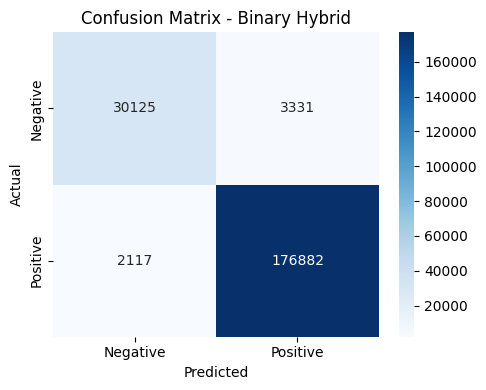


TASK B) HYBRID ORDINAL MULTICLASS (4 cumulative binaries + MAE threshold tuning)

Starting Ordinal Training (4 binaries) on TRAIN (3 epochs)...

--- Epoch 1/3 ---
   Training P(y > 1)


Training (P(y>1)):   0%|          | 0/958686 [00:00<?, ?it/s]

   Training P(y > 2)


Training (P(y>2)):   0%|          | 0/958686 [00:00<?, ?it/s]

   Training P(y > 3)


...

Predict TEST proba P(y>1):   0%|          | 0/239672 [00:00<?, ?it/s]

Predict TEST proba P(y>2):   0%|          | 0/239672 [00:00<?, ?it/s]

Predict TEST proba P(y>3):   0%|          | 0/239672 [00:00<?, ?it/s]

Predict TEST proba P(y>4):   0%|          | 0/239672 [00:00<?, ?it/s]

              precision    recall  f1-score   support

           1       0.75      0.67      0.71     16768
           2       0.47      0.49      0.48     16688
           3       0.53      0.48      0.51     27217
           4       0.56      0.53      0.55     62201
           5       0.80      0.85      0.82    116798

    accuracy                           0.69    239672
   macro avg       0.62      0.60      0.61    239672
weighted avg       0.68      0.69      0.68    239672

Final MAE: 0.34174204746486864


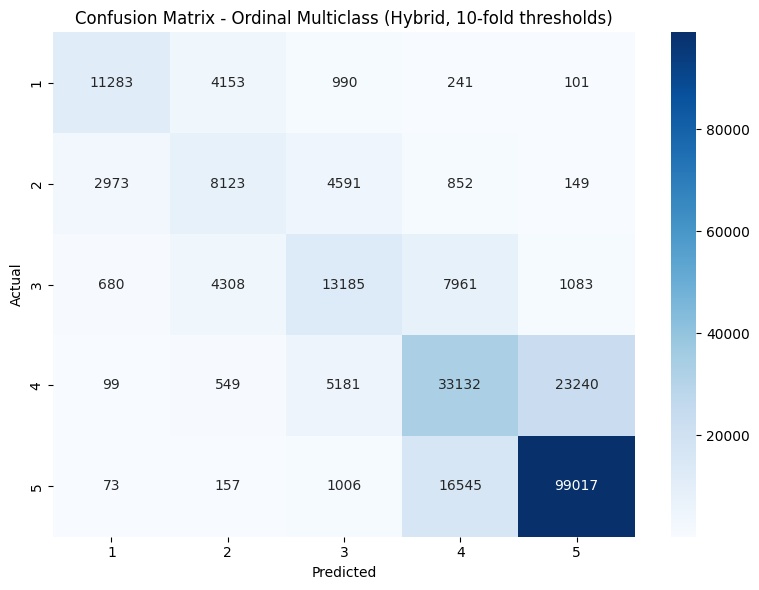

5962

In [1]:
import pandas as pd
import numpy as np
import os
import gc
import joblib
from itertools import product

from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, accuracy_score, confusion_matrix, mean_absolute_error
)
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from google.colab import drive

# ==============================================================================
# 0) CONFIG
# ==============================================================================
RANDOM_STATE = 42
BATCH_SIZE = 10000

# Task A (Simple Binary, as in your first code)
EPOCHS_BIN = 3
VAL_SAMPLE_SIZE = 20000

# Task B (Ordinal: 4 cumulative binaries + threshold tuning)
EPOCHS_ORD = 3
N_SPLITS = 10
THRESHOLD_GRID = [0.3, 0.4, 0.5, 0.6]

# ==============================================================================
# 1) SETUP + LOAD
# ==============================================================================
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/MAGISTRALE/Text_Mining/Datasets'
VECTORS_PATH = os.path.join(DRIVE_PATH, 'vectors')

print("--- PHASE 1: LOADING ---")
print("1) CSV Dataset...")
df_train = pd.read_csv(os.path.join(DRIVE_PATH, 'train_dataset.csv'))
df_test  = pd.read_csv(os.path.join(DRIVE_PATH, 'test_dataset.csv'))

# Reset index to avoid alignment issues
df_train = df_train.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print("2) BERT Vectors (mmap_mode='r')...")
bert_train = np.load(os.path.join(VECTORS_PATH, 'bert_train.npy'), mmap_mode='r')
bert_test  = np.load(os.path.join(VECTORS_PATH, 'bert_test.npy'),  mmap_mode='r')
print(f"   Train BERT Shape: {bert_train.shape}")
print(f"   Test  BERT Shape: {bert_test.shape}")

print("3) TF-IDF Vectors (loaded in RAM)...")
tfidf_train = joblib.load(os.path.join(VECTORS_PATH, 'tfidf_train.pkl'))
tfidf_test  = joblib.load(os.path.join(VECTORS_PATH, 'tfidf_test.pkl'))
print(f"   Train TF-IDF Shape: {tfidf_train.shape}")
print(f"   Test  TF-IDF Shape: {tfidf_test.shape}")

# ==============================================================================
# 2) EXTRA FEATURES
# ==============================================================================
print("\n--- PHASE 2: EXTRA FEATURE PREPARATION ---")
feature_cols = [
    'vader_pos', 'vader_neg', 'vader_neu',
    'num_exclamations', 'caps_ratio', 'review_len_words',
    'review_len_chars', 'num_questions'
]

scaler = MinMaxScaler()
X_train_feats = scaler.fit_transform(np.nan_to_num(df_train[feature_cols].values))
X_test_feats  = scaler.transform(np.nan_to_num(df_test[feature_cols].values))

y_train_original = df_train['stars_review'].reset_index(drop=True)
y_test_original  = df_test['stars_review'].reset_index(drop=True)

# ==============================================================================
# 3) HYBRID FUNCTIONS (BERT + TF-IDF + FEATURES) - batch training/predict/proba
# ==============================================================================
def train_hybrid_epoch(model, indices, X_bert, X_tfidf, X_feats, y_full,
                       batch_size=BATCH_SIZE, classes=None, desc="Training"):
    indices = np.array(indices, dtype=int)
    np.random.shuffle(indices)

    with tqdm(total=len(indices), desc=desc) as pbar:
        for start in range(0, len(indices), batch_size):
            end = min(start + batch_size, len(indices))
            idx = indices[start:end]

            X_batch = np.hstack((
                X_bert[idx],
                X_tfidf[idx].toarray(),
                X_feats[idx]
            ))
            y_batch = y_full.iloc[idx].values

            model.partial_fit(X_batch, y_batch, classes=classes)

            del X_batch
            pbar.update(len(idx))
    return model


def predict_hybrid(model, indices, X_bert, X_tfidf, X_feats,
                   batch_size=BATCH_SIZE, desc="Predict"):
    indices = np.array(indices, dtype=int)
    preds = []

    with tqdm(total=len(indices), desc=desc) as pbar:
        for start in range(0, len(indices), batch_size):
            end = min(start + batch_size, len(indices))
            idx = indices[start:end]

            X_batch = np.hstack((
                X_bert[idx],
                X_tfidf[idx].toarray(),
                X_feats[idx]
            ))
            preds.extend(model.predict(X_batch))

            del X_batch
            pbar.update(len(idx))

    return np.array(preds)


def predict_proba_hybrid_pos(model, indices, X_bert, X_tfidf, X_feats,
                            batch_size=BATCH_SIZE, desc="Predict proba(pos)"):
    """For binary models: returns the probability of class 1."""
    indices = np.array(indices, dtype=int)
    probs = []

    with tqdm(total=len(indices), desc=desc) as pbar:
        for start in range(0, len(indices), batch_size):
            end = min(start + batch_size, len(indices))
            idx = indices[start:end]

            X_batch = np.hstack((
                X_bert[idx],
                X_tfidf[idx].toarray(),
                X_feats[idx]
            ))
            probs.extend(model.predict_proba(X_batch)[:, 1])

            del X_batch
            pbar.update(len(idx))

    return np.array(probs)


def validate_epoch_sample(model, test_indices, X_bert, X_tfidf, X_feats, y_test_full,
                          sample_size=VAL_SAMPLE_SIZE):
    """Accuracy on a random subset of the test set (fast, as in your first code)."""
    test_indices = np.array(test_indices, dtype=int)
    n_take = min(len(test_indices), sample_size)
    subset = np.random.choice(test_indices, size=n_take, replace=False)

    y_pred_sub = predict_hybrid(model, subset, X_bert, X_tfidf, X_feats, desc="Validating")
    y_true_sub = y_test_full.iloc[subset].values
    return accuracy_score(y_true_sub, y_pred_sub)

# ==============================================================================
# 4) TASK A: BINARY (as in your first code) + CONFUSION MATRIX
# ==============================================================================
print("\n" + "="*70)
print("TASK A) HYBRID BINARY CLASSIFICATION (BERT + TF-IDF + FEATURES)")
print("="*70)
print("Logic: exclude 3-star reviews. (1,2)->0 Negative | (4,5)->1 Positive")

train_idx_bin = np.where((y_train_original != 3).values)[0]
test_idx_bin  = np.where((y_test_original  != 3).values)[0]

y_train_bin = y_train_original.apply(lambda x: 0 if x <= 2 else 1)
y_test_bin  = y_test_original.apply(lambda x: 0 if x <= 2 else 1)

model_bin = MLPClassifier(
    hidden_layer_sizes=(512, 128),
    activation='relu',
    solver='adam',
    random_state=RANDOM_STATE,
    max_iter=1,
    warm_start=True,
    verbose=False
)

print(f"\nStarting Binary Training ({EPOCHS_BIN} epochs)...")
for epoch in range(EPOCHS_BIN):
    print(f"\n--- Epoch {epoch+1}/{EPOCHS_BIN} ---")

    model_bin = train_hybrid_epoch(
        model=model_bin,
        indices=train_idx_bin,
        X_bert=bert_train,
        X_tfidf=tfidf_train,
        X_feats=X_train_feats,
        y_full=y_train_bin,
        classes=[0, 1],
        desc="Training (Binary)"
    )

    val_acc = validate_epoch_sample(
        model_bin, test_idx_bin, bert_test, tfidf_test, X_test_feats, y_test_bin
    )
    print(f"   >> 📈 Validation Accuracy (test sample): {val_acc:.4f}")

print("\nFinal Full Evaluation (BINARY)...")
y_pred_bin = predict_hybrid(model_bin, test_idx_bin, bert_test, tfidf_test, X_test_feats, desc="Predict Test (Binary)")
y_true_bin = y_test_bin.iloc[test_idx_bin].values

print(f"\nFinal Binary Accuracy: {accuracy_score(y_true_bin, y_pred_bin):.4f}")
print(classification_report(y_true_bin, y_pred_bin, target_names=['Negative', 'Positive']))

cm_bin = confusion_matrix(y_true_bin, y_pred_bin, labels=[0, 1])
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_bin, annot=True, fmt='d', cmap='Blues',
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.title("Confusion Matrix - Binary Hybrid")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

del model_bin, y_pred_bin
gc.collect()

# ==============================================================================
# 5) TASK B: ORDINAL MULTICLASS (4 cumulative binaries) + threshold tuning (10-fold) + MAE + CONF MAT
#    (multiclass part adapted from your "second code")
# ==============================================================================
print("\n" + "="*70)
print("TASK B) HYBRID ORDINAL MULTICLASS (4 cumulative binaries + MAE threshold tuning)")
print("="*70)

def make_ordinal_targets(y):
    return {
        1: (y > 1).astype(int),
        2: (y > 2).astype(int),
        3: (y > 3).astype(int),
        4: (y > 4).astype(int)
    }

def predict_ordinal(probs_4, thresholds_4):
    return 1 + (probs_4 > thresholds_4).sum(axis=1)

y_train_ord = make_ordinal_targets(y_train_original)

# 5.1) initialize 4 binary models
ordinal_models = {}
for k in [1, 2, 3, 4]:
    ordinal_models[k] = MLPClassifier(
        hidden_layer_sizes=(512, 128),
        activation='relu',
        solver='adam',
        random_state=RANDOM_STATE,
        max_iter=1,
        warm_start=True,
        verbose=False
    )

# 5.2) training on the full train set
train_idx_all = np.arange(len(df_train))

print(f"\nStarting Ordinal Training (4 binaries) on TRAIN ({EPOCHS_ORD} epochs)...")
for epoch in range(EPOCHS_ORD):
    print(f"\n--- Epoch {epoch+1}/{EPOCHS_ORD} ---")
    for k in [1, 2, 3, 4]:
        print(f"   Training P(y > {k})")
        ordinal_models[k] = train_hybrid_epoch(
            model=ordinal_models[k],
            indices=train_idx_all,
            X_bert=bert_train,
            X_tfidf=tfidf_train,
            X_feats=X_train_feats,
            y_full=y_train_ord[k],
            classes=[0, 1],
            desc=f"Training (P(y>{k}))"
        )

# 5.3) train probabilities (in-sample, as in your code)
print("\nComputing TRAIN probabilities (for 10-fold CV thresholds)...")
probs_train = np.zeros((len(train_idx_all), 4), dtype=np.float32)

for i, k in enumerate([1, 2, 3, 4]):
    probs_train[:, i] = predict_proba_hybrid_pos(
        ordinal_models[k],
        train_idx_all,
        bert_train,
        tfidf_train,
        X_train_feats,
        desc=f"Predict TRAIN proba P(y>{k})"
    ).astype(np.float32)

# 5.4) 10-fold threshold tuning (MAE)
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

best_mae = np.inf
best_thresholds = None

print("\nStarting 10-fold CV for threshold tuning (MAE)...")
for thresholds in product(THRESHOLD_GRID, repeat=4):
    fold_mae = []
    thr = np.array(thresholds, dtype=np.float32)

    for _, val_idx in kf.split(probs_train):
        y_val_true = y_train_original.iloc[val_idx].values
        y_val_pred = predict_ordinal(probs_train[val_idx], thr)
        fold_mae.append(mean_absolute_error(y_val_true, y_val_pred))

    mean_mae = float(np.mean(fold_mae))
    if mean_mae < best_mae:
        best_mae = mean_mae
        best_thresholds = thresholds

print("\n==============================")
print("BEST THRESHOLDS (10-fold CV):", best_thresholds)
print("BEST CV MAE:", best_mae)
print("==============================")

# 5.5) final test
print("\nFinal evaluation on TEST set (Ordinal)...")
test_idx_all = np.arange(len(df_test))
probs_test = np.zeros((len(test_idx_all), 4), dtype=np.float32)

for i, k in enumerate([1, 2, 3, 4]):
    probs_test[:, i] = predict_proba_hybrid_pos(
        ordinal_models[k],
        test_idx_all,
        bert_test,
        tfidf_test,
        X_test_feats,
        desc=f"Predict TEST proba P(y>{k})"
    ).astype(np.float32)

y_test_pred_ord = predict_ordinal(probs_test, np.array(best_thresholds, dtype=np.float32))
y_test_true_ord = y_test_original.values

print(classification_report(y_test_true_ord, y_test_pred_ord))
print("Final MAE:", float(mean_absolute_error(y_test_true_ord, y_test_pred_ord)))

plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion_matrix(y_test_true_ord, y_test_pred_ord, labels=[1, 2, 3, 4, 5]),
    annot=True, fmt='d', cmap='Blues',
    xticklabels=[1,2,3,4,5], yticklabels=[1,2,3,4,5]
)
plt.title("Confusion Matrix - Ordinal Multiclass (Hybrid, 10-fold thresholds)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

gc.collect()
